# IFC → Mesh → FEM — Spannungsanalyse

**Modell:** 2 Wände (4×0.2×2.8 m) + 1 Stütze (0.2×0.2×2.8 m) + Deckenplatte (4×4×0.2 m)  
**FEM:** Wand_A als 2D-Scheibe (QUAD4, ebener Spannungszustand) unter Eigengewicht + Deckenlast  
**Ergebnisse:** σ_x, σ_y, τ_xy, von-Mises, Verformung, M(x), Q(x)

```
   z
   ▲  Decke (q = 5 kN/m²)
   │  ████████████████  z=2.8..3.0 m
   │  ████  Wand_A  ████  4×0.2×2.8 m
   │  ████████████████  z=0
   └──────────────────► x
      0               4 m
```

In [1]:
import jax
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
from scipy.interpolate import LinearNDInterpolator
import ifcopenshell
import ifcopenshell.api
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.generate_mesh import get_meshio_cell_type, Mesh, rectangle_mesh, box_mesh
import pathlib, os

DATA_DIR = pathlib.Path('../data')
DATA_DIR.mkdir(exist_ok=True)

print('JAX:', jax.__version__)
print('ifcopenshell:', ifcopenshell.__version__)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



[04-20 21:09:50][INFO] jax_fem: pyamgx not installed. AMGX solver disabled.


JAX: 0.6.2
ifcopenshell: 0.8.5


## 0 — Parameter

Alle geometrischen und lastbezogenen Größen zentral hier anpassen.

In [2]:
# ── Geometrie ─────────────────────────────────────────────
L_WAND  = 4.0    # m — Wandlänge (x)
D_WAND  = 0.20   # m — Wanddicke (y)
H_WAND  = 2.80   # m — Wandhöhe  (z → wird als y in 2D verwendet)

# ── Netz ──────────────────────────────────────────────────
NX = 80          # Elemente in x
NY = 56          # Elemente in z (Höhe)

# ── Material (Stahlbeton, kN + m) ─────────────────────────
E  = 30_000.0    # kN/m²  (C25/30)
nu = 0.2
mu    = E / (2.0 * (1.0 + nu))
lmbda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))

# ── Lasten ────────────────────────────────────────────────
GAMMA_BETON = 25.0   # kN/m³ — Wichte Stahlbeton
Q_DECKE     = 5.0    # kN/m² — Nutzlast aus Decke (gleichmäßig)
# Eigengewicht der Wand als Volumenlast (wird als äquivalente Drucklast aufgebracht)
# G_wand = gamma * D_wand * H (pro lfdm) → auf Oberkante als Flächenlast
G_WAND_FLAECH = GAMMA_BETON * D_WAND  # kN/m² (Eigengewicht der Wand, verteilt auf Wandfläche)
# Deckenlast auf Wandoberkante: Decke 4×4×0.2 m, 4 Lager (2 Wände + Stütze)
# vereinfacht: je Wand trägt 50 % der Deckenlast
A_DECKE_JE_WAND = L_WAND * 4.0 / 2.0    # m² — Grundrissfläche je Wand
G_DECKE = 25.0 * 4.0 * 0.2              # kN/m² Deckenplatte Eigengewicht (bezogen auf Grundriss)
F_DECKE_GESAMT = (G_DECKE + Q_DECKE) * A_DECKE_JE_WAND  # kN gesamt
Q_OBEN = F_DECKE_GESAMT / L_WAND        # kN/m — auf Wandoberkante, linienförmig
# Als Flächenlast auf Oberkante (JaxFEM surface_map): [kN/m²]
T_TOP = Q_OBEN / D_WAND                 # kN/m² auf die Oberkantenfläche

print(f"Wand:  {L_WAND} × {D_WAND} × {H_WAND} m")
print(f"Netz:  {NX} × {NY} = {NX*NY} QUAD4-Elemente")
print(f"E = {E:.0f} kN/m²   ν = {nu}")
print(f"Deckenlast Gesamt je Wand: {F_DECKE_GESAMT:.1f} kN → q_oben = {Q_OBEN:.2f} kN/m")
print(f"Flächenlast Oberkante: T_top = {T_TOP:.2f} kN/m²")

Wand:  4.0 × 0.2 × 2.8 m
Netz:  80 × 56 = 4480 QUAD4-Elemente
E = 30000 kN/m²   ν = 0.2
Deckenlast Gesamt je Wand: 200.0 kN → q_oben = 50.00 kN/m
Flächenlast Oberkante: T_top = 250.00 kN/m²


## 1 — IFC-Modell & 3D-Netz

Gleiche Gebäudestruktur wie `IFC_Mesh_Demo.ipynb` — jetzt mit verbesserter Matplotlib-Visualisierung.

In [3]:
def _box_vf(x0, y0, z0, dx, dy, dz):
    v = [(x0,y0,z0),(x0+dx,y0,z0),(x0+dx,y0+dy,z0),(x0,y0+dy,z0),
         (x0,y0,z0+dz),(x0+dx,y0,z0+dz),(x0+dx,y0+dy,z0+dz),(x0,y0+dy,z0+dz)]
    f = [(0,1,2),(0,2,3),(4,6,5),(4,7,6),(0,1,5),(0,5,4),
         (2,3,7),(2,7,6),(0,3,7),(0,7,4),(1,2,6),(1,6,5)]
    return v, f

model   = ifcopenshell.api.run('project.create_file', version='IFC4')
project = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcProject', name='Demo')
ifcopenshell.api.run('unit.assign_unit', model, length={'is_metric': True, 'raw': 'METRES'})
ctx  = ifcopenshell.api.run('context.add_context', model, context_type='Model')
body = ifcopenshell.api.run('context.add_context', model, context_type='Model',
                             context_identifier='Body', target_view='MODEL_VIEW', parent=ctx)
site     = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcSite',     name='Site')
building = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcBuilding', name='Gebäude')
storey   = ifcopenshell.api.run('root.create_entity', model, ifc_class='IfcBuildingStorey', name='EG')
ifcopenshell.api.run('aggregate.assign_object', model, products=[site],     relating_object=project)
ifcopenshell.api.run('aggregate.assign_object', model, products=[building], relating_object=site)
ifcopenshell.api.run('aggregate.assign_object', model, products=[storey],   relating_object=building)

BAUTEILE = [
    ('IfcWall',   'Wand_A',   0.0, 0.0, 0.0, L_WAND, D_WAND, H_WAND),
    ('IfcWall',   'Wand_B',   0.0, 3.8, 0.0, L_WAND, D_WAND, H_WAND),
    ('IfcColumn', 'Stütze_M', 1.9, 1.9, 0.0, 0.2,    0.2,    H_WAND),
    ('IfcSlab',   'Decke_D1', 0.0, 0.0, H_WAND, 4.0, 4.0,    0.2),
]

COLOR_MAP = {'IfcWall': '#a0c4ff', 'IfcColumn': '#ff6b6b', 'IfcSlab': '#b9fbc0'}
elements_info = []
for ifc_class, name, x0, y0, z0, dx, dy, dz in BAUTEILE:
    elem = ifcopenshell.api.run('root.create_entity', model, ifc_class=ifc_class, name=name)
    v, f = _box_vf(x0, y0, z0, dx, dy, dz)
    rep  = ifcopenshell.api.run('geometry.add_mesh_representation', model,
                                 context=body, vertices=[v], faces=[f])
    ifcopenshell.api.run('geometry.assign_representation', model, product=elem, representation=rep)
    ifcopenshell.api.run('spatial.assign_container', model, relating_structure=storey, products=[elem])
    elements_info.append({'name': name, 'type': ifc_class,
                           'bbox': (onp.array([x0,y0,z0]), onp.array([x0+dx,y0+dy,z0+dz])),
                           'color': COLOR_MAP[ifc_class]})

ifc_path = str(DATA_DIR / 'demo_statik.ifc')
model.write(ifc_path)
print(f'IFC gespeichert: {ifc_path}')
for info, (_, name, x0, y0, z0, dx, dy, dz) in zip(elements_info, BAUTEILE):
    print(f"  {info['type']:12s} {name:12s}: {dx:.1f}×{dy:.2f}×{dz:.1f} m")

IFC gespeichert: ../data/demo_statik.ifc
  IfcWall      Wand_A      : 4.0×0.20×2.8 m
  IfcWall      Wand_B      : 4.0×0.20×2.8 m
  IfcColumn    Stütze_M    : 0.2×0.20×2.8 m
  IfcSlab      Decke_D1    : 4.0×4.00×0.2 m


## 2 — 3D-Visualisierung (Matplotlib)

Verbesserter Viewer: nur Außenflächen jedes Bauteils, transparente Füllung, Kanten sichtbar.  
Kein PyVista nötig — funktioniert zuverlässig im Notebook.

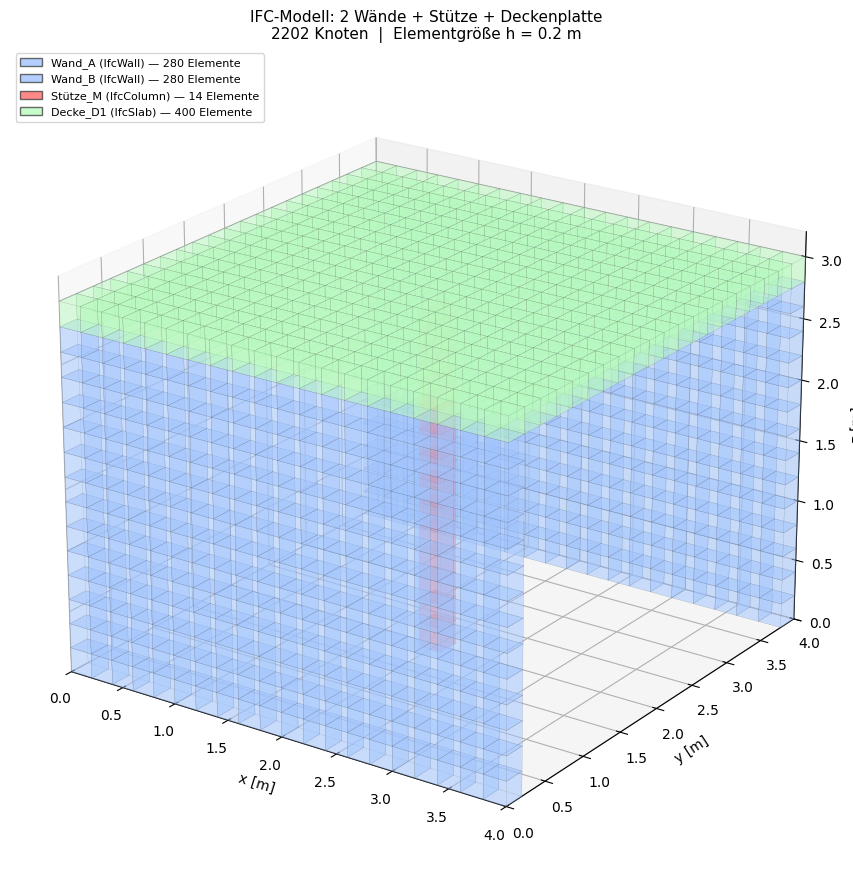

3D-Plot gespeichert.


In [4]:
MESH_SIZE = 0.2   # m — Elementgröße für 3D-Ansicht

HEX_FACES = [
    [0,1,2,3],  # Boden
    [4,5,6,7],  # Deckel
    [0,1,5,4],  # Vorne
    [3,2,6,7],  # Hinten
    [0,3,7,4],  # Links
    [1,2,6,5],  # Rechts
]

# Netz pro Bauteil (HEX8)
mesh_parts = []
all_pts_3d = []
offset = 0
for info, (ifc_class, name, x0, y0, z0, dx, dy, dz) in zip(elements_info, BAUTEILE):
    nx = max(1, int(round(dx / MESH_SIZE)))
    ny = max(1, int(round(dy / MESH_SIZE)))
    nz = max(1, int(round(dz / MESH_SIZE)))
    m   = box_mesh(Nx=nx, Ny=ny, Nz=nz, domain_x=dx, domain_y=dy, domain_z=dz)
    pts = m.points + onp.array([x0, y0, z0])
    cells_loc = m.cells_dict['hexahedron']
    mesh_parts.append({'name': name, 'type': ifc_class, 'color': info['color'],
                       'pts': pts, 'cells': cells_loc + offset,
                       'n_el': len(cells_loc)})
    all_pts_3d.append(pts)
    offset += len(pts)

points_3d = onp.vstack(all_pts_3d)

# ── Plot ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
ax  = fig.add_subplot(111, projection='3d')
legend_handles = []

for part in mesh_parts:
    pts   = part['pts']
    cells = part['cells']
    color = part['color']
    step  = max(1, len(cells) // 400)
    quads = []
    for cell in cells[::step]:
        gpts = points_3d[cell]
        for face in HEX_FACES:
            quads.append(gpts[face])
    poly = Poly3DCollection(quads, alpha=0.30, linewidth=0.15)
    poly.set_facecolor(color)
    poly.set_edgecolor('#444444')
    ax.add_collection3d(poly)
    legend_handles.append(Patch(facecolor=color, edgecolor='#444', alpha=0.8,
                                 label=f"{part['name']} ({part['type']}) — {part['n_el']} Elemente"))

ax.set_xlabel('x [m]', fontsize=10)
ax.set_ylabel('y [m]', fontsize=10)
ax.set_zlabel('z [m]', fontsize=10)
ax.set_title('IFC-Modell: 2 Wände + Stütze + Deckenplatte\n'
             f'{len(points_3d)} Knoten  |  Elementgröße h = {MESH_SIZE} m', fontsize=11)
ax.set_xlim(0, 4); ax.set_ylim(0, 4); ax.set_zlim(0, 3.2)
ax.set_box_aspect([4, 4, 3.2])
ax.view_init(elev=22, azim=-55)
ax.legend(handles=legend_handles, loc='upper left', fontsize=8)
plt.tight_layout()

os.makedirs(str(DATA_DIR / 'vtk'), exist_ok=True)
plt.savefig(str(DATA_DIR / 'vtk' / 'ifc_mesh_3d.png'), dpi=150, bbox_inches='tight')
plt.show()
print('3D-Plot gespeichert.')

## 2b — Interaktiver 3D-Viewer mit PyVista

PyVista rendert das Netz interaktiv (drehen, zoomen, Bauteilfarben).  
Im Notebook wird ein statisches PNG ausgegeben (`static` backend).

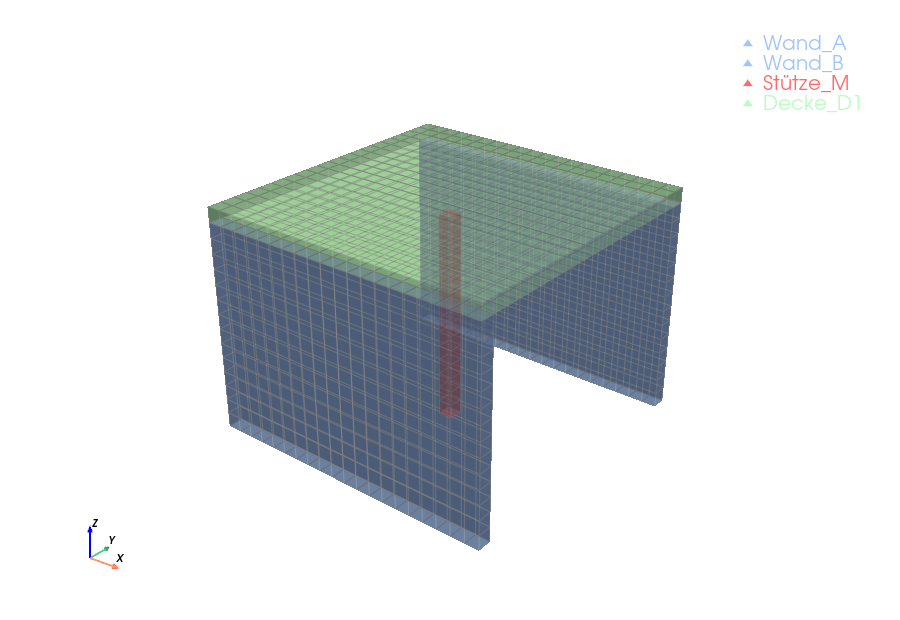

In [5]:
import pyvista as pv

pv.set_jupyter_backend('static')

PV_COLORS = {
    'IfcWall':   '#a0c4ff',
    'IfcColumn': '#ff6b6b',
    'IfcSlab':   '#b9fbc0',
}

plotter = pv.Plotter(window_size=(900, 620))
plotter.set_background('white')

for part in mesh_parts:
    pts   = part['pts']
    cells = part['cells']
    local_offset = int(cells.min())
    local_cells  = cells - local_offset
    cell_array = onp.hstack([
        onp.full((len(local_cells), 1), 8, dtype=onp.int64),
        local_cells.astype(onp.int64)
    ]).flatten()
    cell_types = onp.full(len(local_cells), pv.CellType.HEXAHEDRON)
    grid = pv.UnstructuredGrid(cell_array, cell_types, pts)
    plotter.add_mesh(grid,
                     color=PV_COLORS[part['type']],
                     show_edges=True,
                     edge_color='gray',
                     opacity=0.85,
                     label=part['name'])

plotter.add_legend(size=(0.22, 0.14), loc='upper right')
plotter.add_axes()
plotter.camera_position = [(10, -8, 8), (2, 2, 1.5), (0, 0, 1)]
plotter.show(title='IFC-Mesh — 2 Wände + Stütze + Decke')

## 3 — FEM-Modell: Wand_A als 2D-Scheibe

**Modellierungsannahmen:**
- Ebener Spannungszustand (Scheibendicke b = 0.2 m)
- x-Achse = Wandlänge (0..4 m), y-Achse = Wandhöhe (0..2.8 m)
- Lagerung: Fundament = Einspannung an y = 0 (u_x = u_y = 0)
- Last: Gleichmäßige Drucklast auf Oberkante (y = H) aus Deckengewicht + Nutzlast

```
  ↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓  q_oben [kN/m²] (Decke + Nutzlast)
  ┌───────────────────┐  y = H = 2.8 m
  │                   │
  │     WAND_A        │  Stahlbeton E=30000 kN/m²
  │                   │
  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓  y = 0 (Einspannung)
```

In [6]:
ele_type  = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

meshio_mesh = rectangle_mesh(Nx=NX, Ny=NY, domain_x=L_WAND, domain_y=H_WAND)
mesh_fem    = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
points_fem  = meshio_mesh.points   # (N, 2)  x = Länge, y = Höhe

print(f'Netz: {len(points_fem)} Knoten, {len(meshio_mesh.cells_dict[cell_type])} QUAD4-Elemente')
print(f'Δx = {L_WAND/NX:.4f} m  Δy = {H_WAND/NY:.4f} m')

tol = (L_WAND / NX) * 0.6

def zero(p): return 0.0

def bottom(p):   return np.isclose(p[1], 0.0,    atol=tol)
def top(p):      return np.isclose(p[1], H_WAND, atol=tol)

# Einspannung unten: u_x = u_y = 0
dirichlet_bc_info = [
    [bottom, bottom],
    [0,      1     ],
    [zero,   zero  ],
]

class WandScheibe(Problem):
    def get_tensor_map(self):
        def stress(u_grad):
            eps = 0.5 * (u_grad + u_grad.T)
            return lmbda * np.trace(eps) * np.eye(self.dim) + 2.0 * mu * eps
        return stress

    def get_surface_maps(self):
        def load_top(u, x):
            # Positives t_y = Druck nach unten (JaxFEM-Konvention)
            return np.array([0.0, T_TOP])
        return [load_top]

problem = WandScheibe(
    mesh=mesh_fem, vec=2, dim=2,
    ele_type=ele_type,
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=[top],
)
print('Problem aufgestellt.')

[04-20 21:09:51][DEBUG] jax_fem: Computing shape function values, gradients, etc.


[04-20 21:09:51][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)


[04-20 21:09:51][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)


Netz: 4617 Knoten, 4480 QUAD4-Elemente
Δx = 0.0500 m  Δy = 0.0500 m


[04-20 21:09:52][DEBUG] jax_fem: Done pre-computations, took 0.20505380630493164 [s]


[04-20 21:09:52][INFO] jax_fem: Solving a problem with 4480 cells, 4617x2 = 9234 dofs.


[04-20 21:09:52][INFO] jax_fem: Element type is QUAD4, using 4 quad points per element.


Problem aufgestellt.


## 4 — Lösen

In [7]:
sol = solver(problem, solver_options={'umfpack_solver': {}})

ux = onp.array(sol[0][:, 0])
uy = onp.array(sol[0][:, 1])

print(f'u_x: min={ux.min()*1000:.4f} mm  max={ux.max()*1000:.4f} mm')
print(f'u_y: min={uy.min()*1000:.4f} mm  max={uy.max()*1000:.4f} mm')

[04-20 21:09:52][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.


[04-20 21:09:52][DEBUG] jax_fem: Start timing


[04-20 21:09:52][DEBUG] jax_fem: Computing cell Jacobian and cell residual...


[04-20 21:09:52][DEBUG] jax_fem: Function split_and_compute_cell took 0.0465 seconds


[04-20 21:09:52][DEBUG] jax_fem: Creating sparse matrix with scipy...


...

[04-20 21:09:52][DEBUG] jax_fem: l_2 res = 1.794026736269259e-11, relative l_2 res = 1.609664379834279e-13


[04-20 21:09:52][INFO] jax_fem: Solve took 0.5528440475463867 [s]


[04-20 21:09:52][INFO] jax_fem: max of dofs = 0.004325377572402844


[04-20 21:09:52][INFO] jax_fem: min of dofs = -0.02260229359247963


u_x: min=-4.3254 mm  max=4.3254 mm
u_y: min=-22.6023 mm  max=0.0000 mm


## 5 — Spannungsberechnung (Gauss-Punkt-Extrapolation)

In [8]:
def compute_stress_strain(points_2d, cells_2d, sol_array):
    """Spannungen + Dehnungen an Gauss-Punkten → Nearest-Neighbor auf Knoten."""
    gauss_1d = onp.array([-1/onp.sqrt(3), 1/onp.sqrt(3)])
    gp_pairs = [(xi, eta) for xi in gauss_1d for eta in gauss_1d]

    gp_coords, sigmas, epses = [], [], []

    for cell in cells_2d:
        xc = points_2d[cell]      # (4, 2)
        uc = sol_array[cell]      # (4, 2)
        for xi, eta in gp_pairs:
            N = onp.array([
                0.25*(1-xi)*(1-eta), 0.25*(1+xi)*(1-eta),
                0.25*(1+xi)*(1+eta), 0.25*(1-xi)*(1+eta),
            ])
            dN = onp.array([
                [-(1-eta), -(1-xi)], [(1-eta), -(1+xi)],
                [(1+eta),  (1+xi)], [-(1+eta), (1-xi)],
            ]) * 0.25
            J    = dN.T @ xc
            Jinv = onp.linalg.inv(J)
            dNdx = dN @ Jinv.T
            x_gp = N @ xc
            gu   = dNdx.T @ uc
            eps  = 0.5 * (gu + gu.T)
            exx, eyy, exy = eps[0,0], eps[1,1], eps[0,1]
            sxx = (lmbda + 2*mu)*exx + lmbda*eyy
            syy = lmbda*exx + (lmbda + 2*mu)*eyy
            sxy = 2*mu*exy
            gp_coords.append(x_gp)
            sigmas.append([sxx, syy, sxy])
            epses.append([exx, eyy, exy])

    gp_coords = onp.array(gp_coords)
    sigmas    = onp.array(sigmas)
    epses     = onp.array(epses)
    _, idx    = cKDTree(gp_coords).query(points_2d)
    return sigmas[idx], epses[idx]

cells_2d = meshio_mesh.cells_dict[cell_type]
sigma_n, eps_n = compute_stress_strain(points_fem, cells_2d, onp.array(sol[0]))

sxx = sigma_n[:, 0]
syy = sigma_n[:, 1]
sxy = sigma_n[:, 2]
exx = eps_n[:,   0]
eyy = eps_n[:,   1]
exy = eps_n[:,   2]
s_vm = onp.sqrt(sxx**2 - sxx*syy + syy**2 + 3*sxy**2)

# Verformte Geometrie (Überhöhung)
max_disp = max(abs(ux).max(), abs(uy).max())
scale = min(0.15 * H_WAND / max(max_disp, 1e-12), 200.0)
scale = max(round(scale, 0), 1.0)
x_def = points_fem[:, 0] + scale * ux
y_def = points_fem[:, 1] + scale * uy

print(f'σ_xx: {sxx.min():.1f} … {sxx.max():.1f} kN/m²')
print(f'σ_yy: {syy.min():.1f} … {syy.max():.1f} kN/m²')
print(f'τ_xy: {sxy.min():.1f} … {sxy.max():.1f} kN/m²')
print(f'σ_vm: max = {s_vm.max():.1f} kN/m²')
print(f'Überhöhungsfaktor: ×{scale:.0f}')

σ_xx: -95.3 … 9.3 kN/m²
σ_yy: -452.0 … -235.0 kN/m²
τ_xy: -92.2 … 92.2 kN/m²
σ_vm: max = 442.5 kN/m²
Überhöhungsfaktor: ×19


## 6 — Verformungsplot (u_x, u_y)

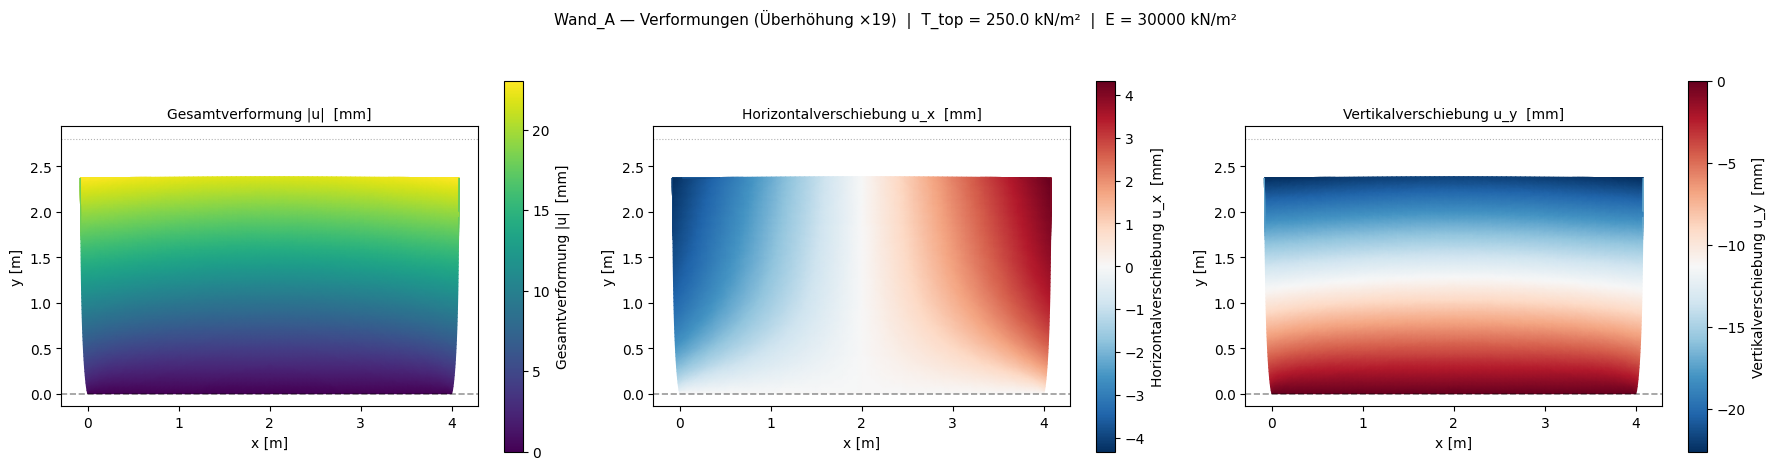

In [9]:
u_total = onp.sqrt(ux**2 + uy**2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (u_total * 1000, 'Gesamtverformung |u|  [mm]', 'viridis'),
    (ux      * 1000, 'Horizontalverschiebung u_x  [mm]', 'RdBu_r'),
    (uy      * 1000, 'Vertikalverschiebung u_y  [mm]',   'RdBu_r'),
]
for ax, (data, label, cmap) in zip(axes, datasets):
    sc = ax.tripcolor(x_def, y_def, data, shading='gouraud', cmap=cmap)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.85)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.set_aspect('equal')
    ax.axhline(0,          color='k', lw=1.2, ls='--', alpha=0.4)
    ax.axhline(H_WAND,     color='k', lw=0.8, ls=':',  alpha=0.3)

plt.suptitle(f'Wand_A — Verformungen (Überhöhung ×{scale:.0f})  |  '
             f'T_top = {T_TOP:.1f} kN/m²  |  E = {E:.0f} kN/m²', fontsize=11)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'vtk' / 'wand_verformung.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7 — Spannungsplots (σ_x, σ_y, τ_xy, von-Mises)

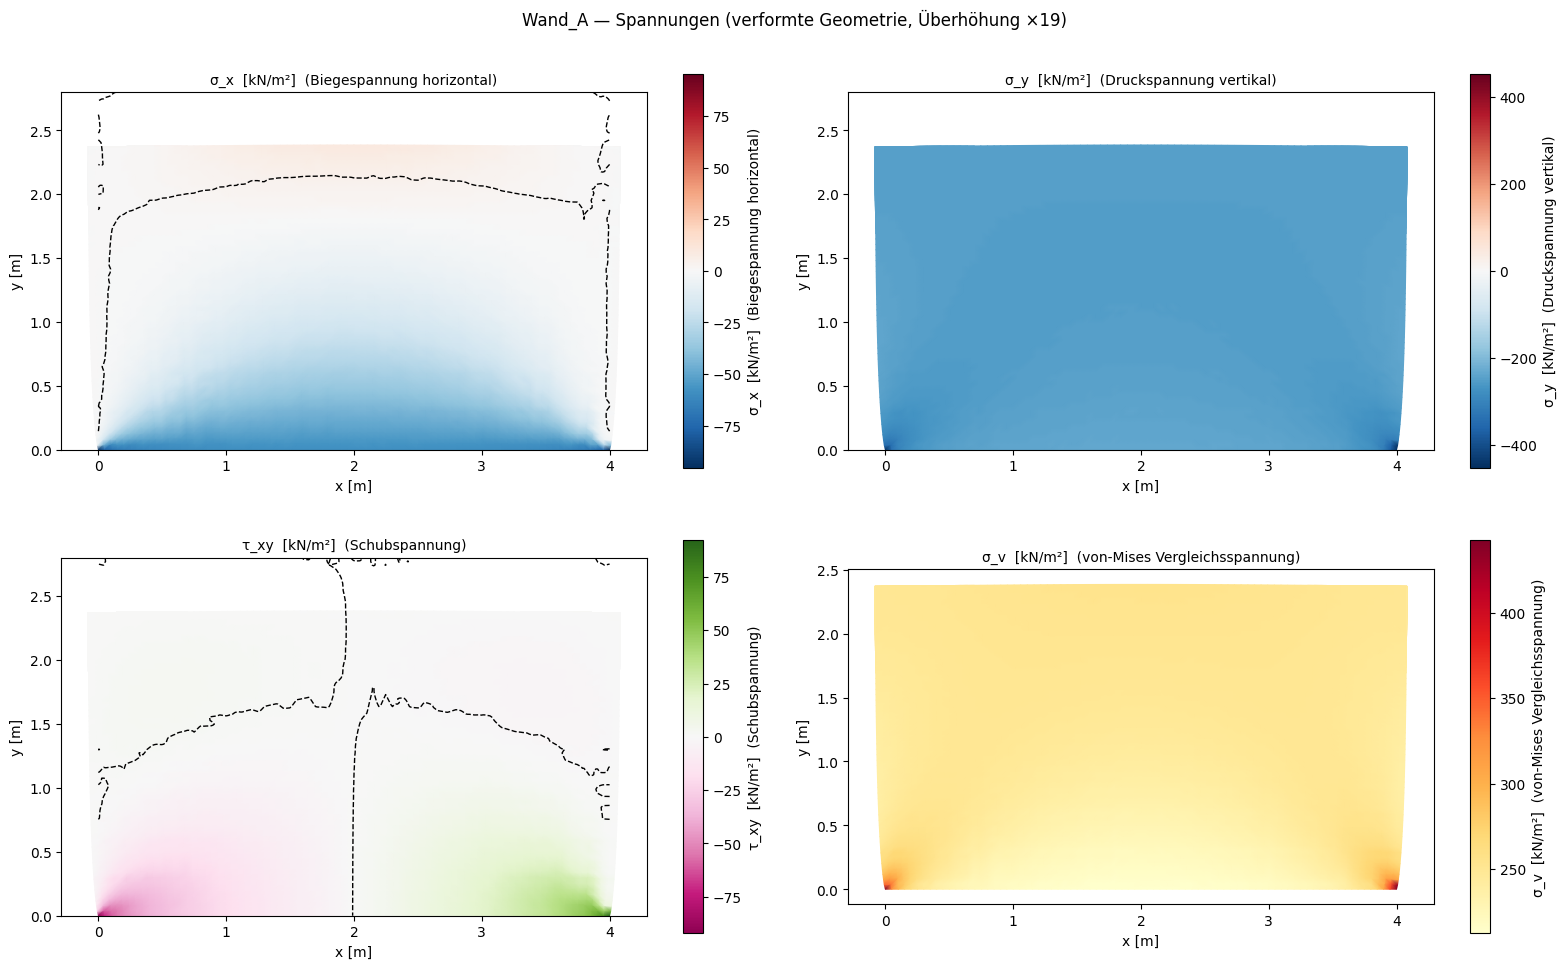

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

plots_sigma = [
    (sxx,  'σ_x  [kN/m²]  (Biegespannung horizontal)', 'RdBu_r'),
    (syy,  'σ_y  [kN/m²]  (Druckspannung vertikal)',   'RdBu_r'),
    (sxy,  'τ_xy  [kN/m²]  (Schubspannung)',            'PiYG'),
    (s_vm, 'σ_v  [kN/m²]  (von-Mises Vergleichsspannung)', 'YlOrRd'),
]

for ax, (data, label, cmap) in zip(axes, plots_sigma):
    # Symmetrische Farbskala für vorzeichenbehaftete Größen
    if cmap in ('RdBu_r', 'PiYG'):
        vmax = onp.abs(data).max()
        sc = ax.tripcolor(x_def, y_def, data, shading='gouraud',
                          cmap=cmap, vmin=-vmax, vmax=vmax)
    else:
        sc = ax.tripcolor(x_def, y_def, data, shading='gouraud', cmap=cmap)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.85)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.set_aspect('equal')
    # Nulllinie einzeichnen (nur bei vorzeichenbehafteten)
    if cmap in ('RdBu_r', 'PiYG'):
        try:
            xi_c = onp.linspace(0, L_WAND, 300)
            yi_c = onp.linspace(0, H_WAND, 100)
            Xi_c, Yi_c = onp.meshgrid(xi_c, yi_c)
            interp_d = LinearNDInterpolator(points_fem, data)
            D_c = interp_d(onp.column_stack([Xi_c.ravel(), Yi_c.ravel()])).reshape(100, 300)
            ax.contour(Xi_c, Yi_c, D_c, levels=[0], colors='black', linewidths=1.0, linestyles='--')
        except Exception:
            pass

plt.suptitle(f'Wand_A — Spannungen (verformte Geometrie, Überhöhung ×{scale:.0f})',
             fontsize=12)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'vtk' / 'wand_spannungen.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8 — Hauptspannungen & Trajektorien

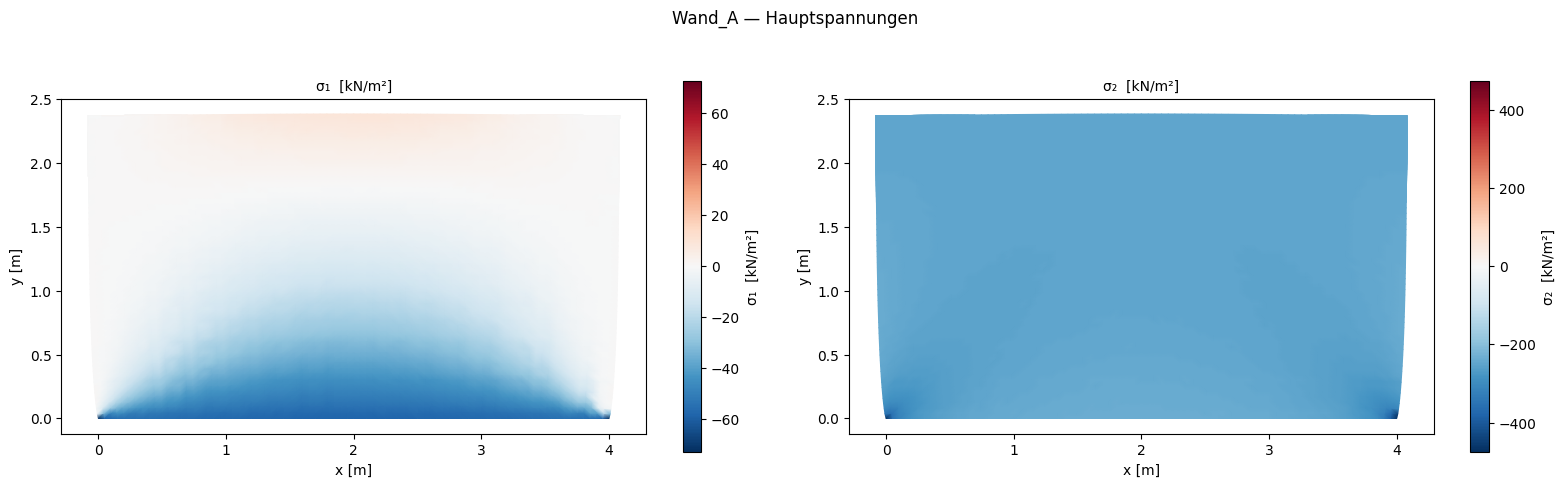

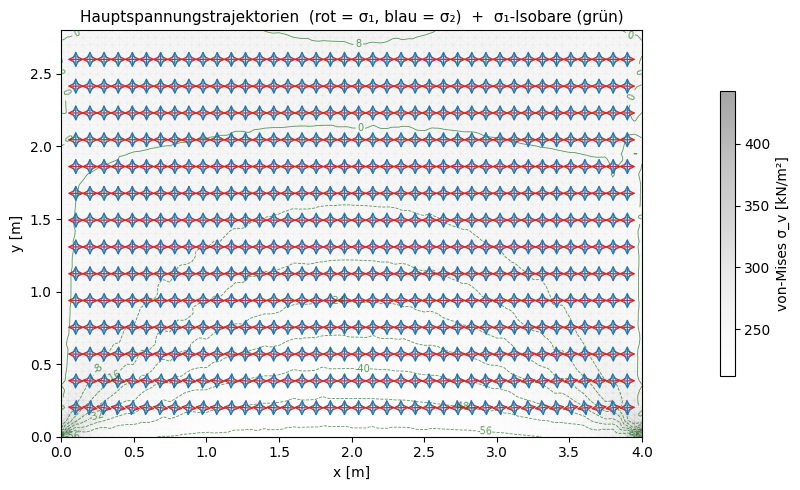

In [11]:
s1 = 0.5*(sxx + syy) + onp.sqrt((0.5*(sxx - syy))**2 + sxy**2)
s2 = 0.5*(sxx + syy) - onp.sqrt((0.5*(sxx - syy))**2 + sxy**2)
theta = 0.5 * onp.arctan2(2*sxy, sxx - syy)
e1x, e1y = onp.cos(theta), onp.sin(theta)
e2x, e2y = -onp.sin(theta), onp.cos(theta)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (data, label) in zip(axes, [(s1, 'σ₁  [kN/m²]'), (s2, 'σ₂  [kN/m²]')]):
    vmax = onp.abs(data).max()
    sc = ax.tripcolor(x_def, y_def, data, shading='gouraud',
                      cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.85)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.set_aspect('equal')

plt.suptitle('Wand_A — Hauptspannungen', fontsize=12)
plt.tight_layout()
plt.show()

# Trajektorienplot
interp_e1x = LinearNDInterpolator(points_fem, e1x)
interp_e1y = LinearNDInterpolator(points_fem, e1y)
interp_e2x = LinearNDInterpolator(points_fem, e2x)
interp_e2y = LinearNDInterpolator(points_fem, e2y)
interp_vm  = LinearNDInterpolator(points_fem, s_vm)
interp_s1  = LinearNDInterpolator(points_fem, s1)

nx_q, ny_q = 40, 14
xq = onp.linspace(L_WAND/nx_q, L_WAND*(1-1/nx_q), nx_q)
yq = onp.linspace(H_WAND/ny_q, H_WAND*(1-1/ny_q), ny_q)
Xq, Yq = onp.meshgrid(xq, yq)
pts_q = onp.column_stack([Xq.ravel(), Yq.ravel()])
E1x = interp_e1x(pts_q).reshape(ny_q, nx_q)
E1y = interp_e1y(pts_q).reshape(ny_q, nx_q)
E2x = interp_e2x(pts_q).reshape(ny_q, nx_q)
E2y = interp_e2y(pts_q).reshape(ny_q, nx_q)

fig, ax = plt.subplots(figsize=(16, 5))
sc = ax.tripcolor(points_fem[:,0], points_fem[:,1], s_vm,
                  shading='gouraud', cmap='Greys', alpha=0.35)
plt.colorbar(sc, ax=ax, label='von-Mises σ_v [kN/m²]', shrink=0.7)

hl = (H_WAND / ny_q) * 0.38
for i in range(ny_q):
    for j in range(nx_q):
        x0, y0 = Xq[i,j], Yq[i,j]
        dx1, dy1 = E1x[i,j], E1y[i,j]
        dx2, dy2 = E2x[i,j], E2y[i,j]
        if onp.isnan(dx1): continue
        ax.annotate('', xy=(x0+dx1*hl, y0+dy1*hl), xytext=(x0-dx1*hl, y0-dy1*hl),
                    arrowprops=dict(arrowstyle='<->', color='tab:red', lw=0.9))
        ax.annotate('', xy=(x0+dx2*hl, y0+dy2*hl), xytext=(x0-dx2*hl, y0-dy2*hl),
                    arrowprops=dict(arrowstyle='<->', color='tab:blue', lw=0.9))

try:
    xi_c = onp.linspace(0, L_WAND, 300)
    yi_c = onp.linspace(0, H_WAND, 80)
    Xi_c, Yi_c = onp.meshgrid(xi_c, yi_c)
    S1_c = interp_s1(onp.column_stack([Xi_c.ravel(), Yi_c.ravel()])).reshape(80, 300)
    cs = ax.contour(Xi_c, Yi_c, S1_c, levels=10, colors='darkgreen', linewidths=0.6, alpha=0.65)
    ax.clabel(cs, fmt='%.0f', fontsize=7)
except Exception:
    pass

ax.set_xlim(0, L_WAND); ax.set_ylim(0, H_WAND)
ax.set_aspect('equal')
ax.set_title('Hauptspannungstrajektorien  (rot = σ₁, blau = σ₂)  +  σ₁-Isobare (grün)', fontsize=11)
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'vtk' / 'wand_trajektorien.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9 — Schnittgrößen: Biegemoment M(x), Querkraft Q(x), Normalkraft N(x)

Die Schnittgrößen werden aus dem FEM-Spannungsfeld durch **Integration über den Querschnitt** gewonnen.

| Schnittgröße | Formel |
|---|---|
| Normalkraft N | $N(x) = \int_0^H \sigma_x \, dy$ |
| Querkraft Q | $Q(x) = \int_0^H \tau_{xy} \, dy$ |
| Biegemoment M | $M(x) = \int_0^H \sigma_x \cdot (y - H/2) \, dy$ |

Integration numerisch per Trapezregel auf einer vertikalen Schnittlinie bei jedem x.

/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/ipykernel_14212/2737757297.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  N_x = onp.trapz(Sxx_g, ys_grid, axis=0)  # kN/m  (Kraft je Länge in z-Richtung)
/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/ipykernel_14212/2737757297.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Q_x = onp.trapz(Sxy_g, ys_grid, axis=0)
/var/folders/cp/39_fchjx57dblvcrzdcvk5gw0000gn/T/ipykernel_14212/2737757297.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_x = onp.trapz(Sxx_g * yc[:, None], ys_grid, axis=0)  # kNm/m


N_max = -2.5 kN/m   N_min = -47.2 kN/m
Q_max = 18.9 kN/m   Q_min = -18.4 kN/m
M_max = 42.75 kNm/m  M_min = 3.65 kNm/m


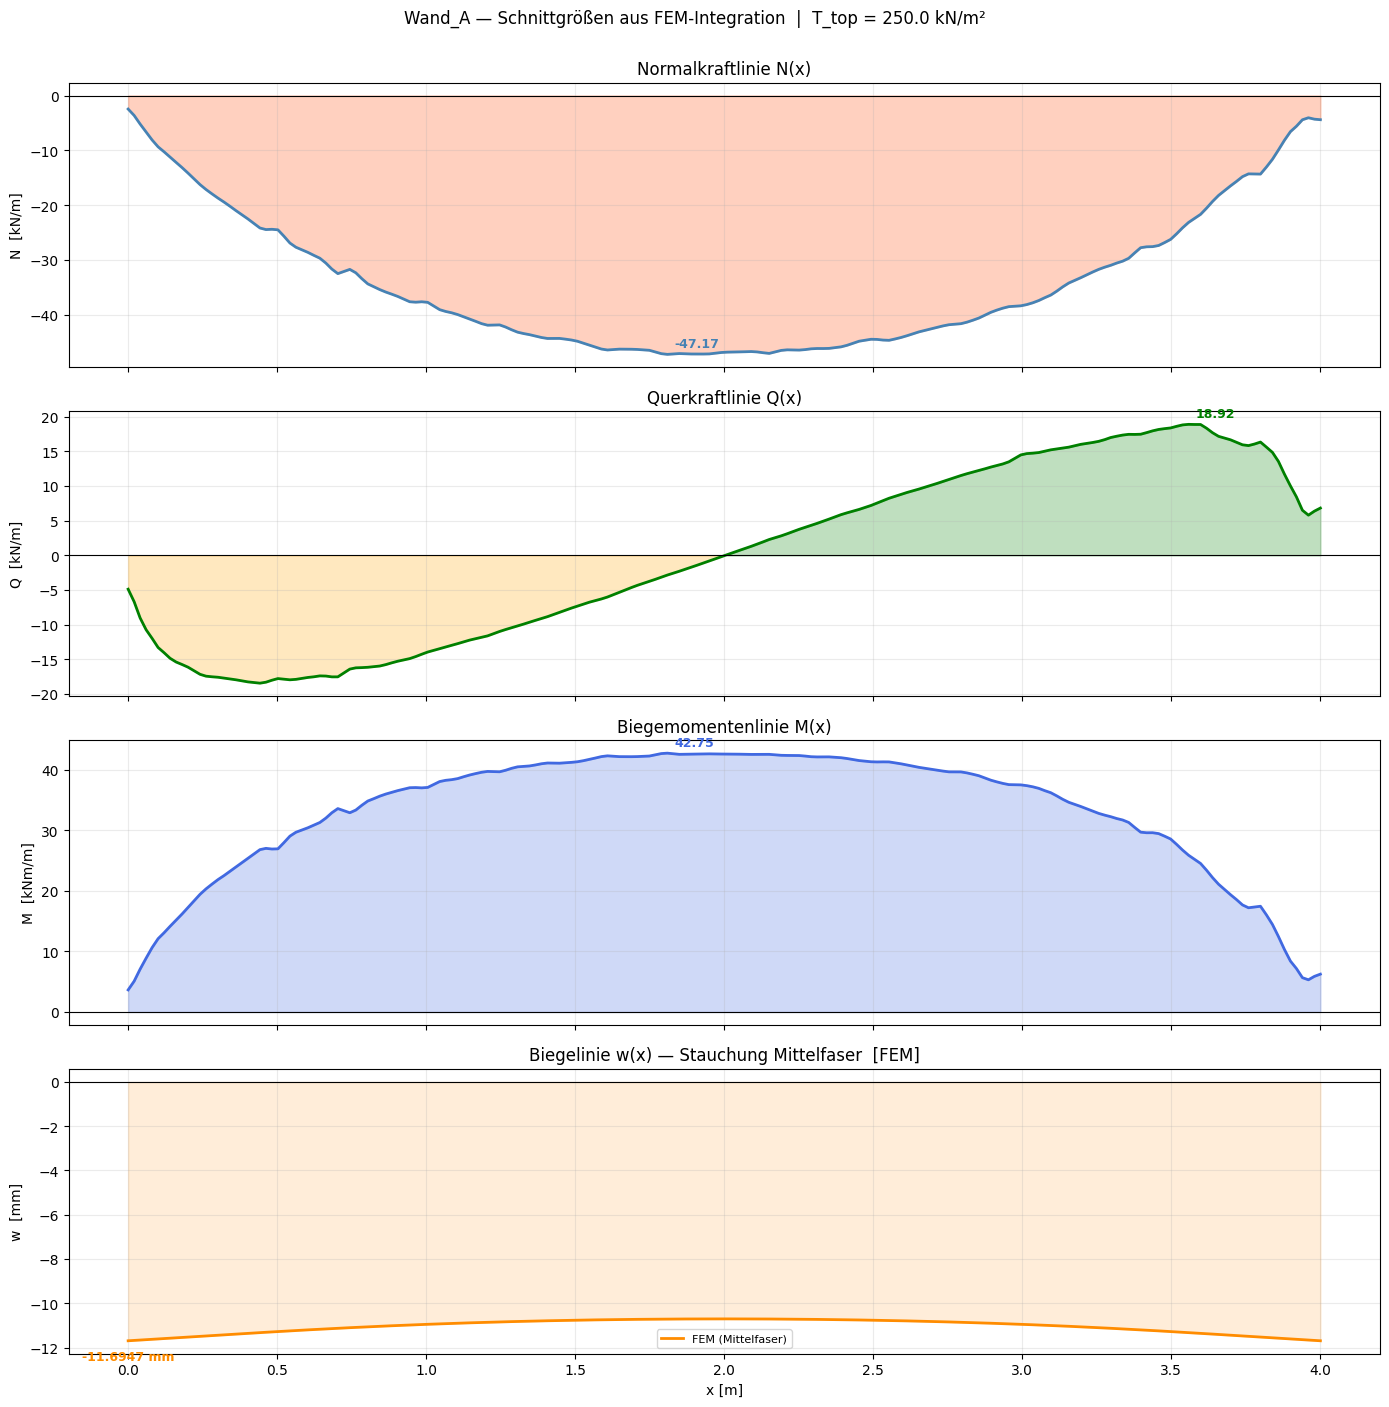

In [12]:
# Interpolatoren auf regulärem Gitter
nx_s = 200
ny_s = 100
xs_grid = onp.linspace(0, L_WAND, nx_s)
ys_grid = onp.linspace(0, H_WAND, ny_s)
Xs, Ys  = onp.meshgrid(xs_grid, ys_grid)
pts_s   = onp.column_stack([Xs.ravel(), Ys.ravel()])

interp_sxx = LinearNDInterpolator(points_fem, sxx)
interp_syy = LinearNDInterpolator(points_fem, syy)
interp_sxy = LinearNDInterpolator(points_fem, sxy)
interp_uy  = LinearNDInterpolator(points_fem, uy)

Sxx_g = interp_sxx(pts_s).reshape(ny_s, nx_s)
Syy_g = interp_syy(pts_s).reshape(ny_s, nx_s)
Sxy_g = interp_sxy(pts_s).reshape(ny_s, nx_s)
Uy_g  = interp_uy(pts_s).reshape(ny_s, nx_s)

dy_s = H_WAND / (ny_s - 1)
yc   = ys_grid - H_WAND / 2.0   # Abstand zur Schwerachse

# Integration über Höhe (Trapez) → Schnittgröße pro x
N_x = onp.trapz(Sxx_g, ys_grid, axis=0)  # kN/m  (Kraft je Länge in z-Richtung)
Q_x = onp.trapz(Sxy_g, ys_grid, axis=0)
M_x = onp.trapz(Sxx_g * yc[:, None], ys_grid, axis=0)  # kNm/m
# Biegelinie (mittlere Faser)
w_x = Uy_g[ny_s//2, :] * 1000  # mm

print(f'N_max = {N_x.max():.1f} kN/m   N_min = {N_x.min():.1f} kN/m')
print(f'Q_max = {Q_x.max():.1f} kN/m   Q_min = {Q_x.min():.1f} kN/m')
print(f'M_max = {M_x.max():.2f} kNm/m  M_min = {M_x.min():.2f} kNm/m')

# ── Schnittgrößendiagramme ───────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True,
                          gridspec_kw={'height_ratios': [1, 1, 1, 1]})

def fill_plot(ax, x, y, color_pos, color_neg, ylabel, title):
    ax.plot(x, y, color=color_pos, lw=2)
    ax.fill_between(x, 0, y, where=(y >= 0), alpha=0.25, color=color_pos)
    ax.fill_between(x, 0, y, where=(y <  0), alpha=0.25, color=color_neg)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(True, alpha=0.25)
    # Extremwertannotation
    i_max = onp.argmax(onp.abs(y))
    ax.annotate(f'{y[i_max]:.2f}', xy=(x[i_max], y[i_max]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, color=color_pos, fontweight='bold')

fill_plot(axes[0], xs_grid, N_x, 'steelblue', 'orangered',
          'N  [kN/m]', 'Normalkraftlinie N(x)')
fill_plot(axes[1], xs_grid, Q_x, 'green', 'orange',
          'Q  [kN/m]', 'Querkraftlinie Q(x)')
fill_plot(axes[2], xs_grid, M_x, 'royalblue', 'red',
          'M  [kNm/m]', 'Biegemomentenlinie M(x)')

# Biegelinie (vertikale Verschiebung der Mittelfaser)
axes[3].plot(xs_grid, w_x, color='darkorange', lw=2, label='FEM (Mittelfaser)')
axes[3].fill_between(xs_grid, 0, w_x, alpha=0.15, color='darkorange')
axes[3].axhline(0, color='black', lw=0.8)
i_w = onp.argmin(w_x)
axes[3].annotate(f'{w_x[i_w]:.4f} mm', xy=(xs_grid[i_w], w_x[i_w]),
                 xytext=(0, -14), textcoords='offset points', ha='center',
                 fontsize=9, color='darkorange', fontweight='bold')
axes[3].set_ylabel('w  [mm]'); axes[3].set_xlabel('x [m]')
axes[3].set_title('Biegelinie w(x) — Stauchung Mittelfaser  [FEM]')
axes[3].legend(fontsize=8); axes[3].grid(True, alpha=0.25)

plt.suptitle(f'Wand_A — Schnittgrößen aus FEM-Integration  |  '
             f'T_top = {T_TOP:.1f} kN/m²', fontsize=12, y=1.002)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'vtk' / 'wand_schnittgroessen.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10 — Querschnittsplot: σ_x-Verteilung über Wandhöhe

Vergleich FEM vs. analytische Biegespannungsverteilung (Euler-Bernoulli) an drei Positionen.

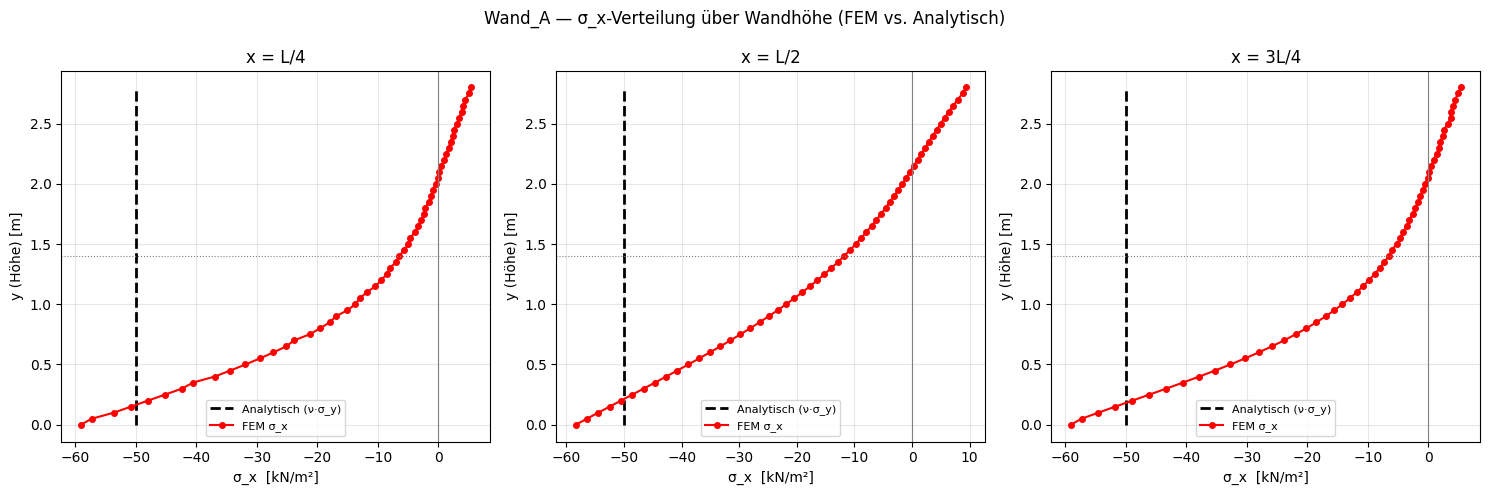

In [13]:
I_wand = 1.0 * H_WAND**3 / 12.0   # m⁴ (Breite b=1 m)
y_c    = H_WAND / 2.0
tol_x  = (L_WAND / NX) * 0.7

x_cuts = {'x = L/4': L_WAND/4, 'x = L/2': L_WAND/2, 'x = 3L/4': 3*L_WAND/4}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, x_cut) in zip(axes, x_cuts.items()):
    mask = onp.abs(points_fem[:, 0] - x_cut) < tol_x
    y_s  = points_fem[mask, 1]
    s_s  = sxx[mask]
    idx  = onp.argsort(y_s)

    # Analytisches Biegemoment an diesem Schnitt (Einspannung unten, Last oben)
    # Für gleichmäßige Drucklast T_TOP auf Oberkante:
    # Als Scheibe unter reiner Drucklast: σ_y dominiert, σ_x ≈ 0 analytisch
    # Stattdessen: σ_x aus Querbiegewirkung (Wandscheibe unter Drucklast hat σ_x = ν*σ_y)
    # σ_y analytisch ≈ -T_TOP (konstant über Höhe für schlanke Wand)
    sigma_y_ana_val = -T_TOP   # kN/m² (Drucklast)
    sigma_x_ana_arr = nu * sigma_y_ana_val * onp.ones(200)   # Querdehnungseffekt
    y_ana  = onp.linspace(0, H_WAND, 200)

    ax.plot(sigma_x_ana_arr, y_ana, 'k--', lw=2, label='Analytisch (ν·σ_y)')
    ax.plot(s_s[idx], y_s[idx], 'ro-', ms=4, lw=1.5, label='FEM σ_x')
    ax.axvline(0,   color='gray', lw=0.8)
    ax.axhline(y_c, color='gray', lw=0.8, ls=':')
    ax.set_xlabel('σ_x  [kN/m²]')
    ax.set_ylabel('y (Höhe) [m]')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Wand_A — σ_x-Verteilung über Wandhöhe (FEM vs. Analytisch)', fontsize=12)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'vtk' / 'wand_querschnitt_sxx.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11 — Zusammenfassung

| Größe | Wert |
|-------|------|
| Deckenauflast je Wand | `F_DECKE_GESAMT` kN |
| σ_y max (Druck) | `syy.min()` kN/m² |
| von-Mises max | `s_vm.max()` kN/m² |
| Stauchung w_max | `uy.min()*1000` mm |

In [14]:
print('=' * 55)
print('  Zusammenfassung — Wand_A FEM-Analyse')
print('=' * 55)
print(f'  Geometrie       : {L_WAND} × {D_WAND} × {H_WAND} m')
print(f'  Material        : E = {E:.0f} kN/m²   ν = {nu}')
print(f'  Deckenlast      : {F_DECKE_GESAMT:.1f} kN gesamt → q = {Q_OBEN:.2f} kN/m')
print(f'  Flächenlast     : T_top = {T_TOP:.2f} kN/m²')
print('-' * 55)
print(f'  σ_x   min/max   : {sxx.min():.1f} / {sxx.max():.1f} kN/m²')
print(f'  σ_y   min/max   : {syy.min():.1f} / {syy.max():.1f} kN/m²')
print(f'  τ_xy  min/max   : {sxy.min():.1f} / {sxy.max():.1f} kN/m²')
print(f'  σ_vm  max       : {s_vm.max():.1f} kN/m²')
print(f'  u_y   max (Stauchung): {uy.min()*1000:.4f} mm')
print(f'  u_x   max (Horizontal): {max(abs(ux.min()), abs(ux.max()))*1000:.4f} mm')
print('=' * 55)
print('\nNächste Schritte:')
print('  → Wand_B und Stütze_M analog berechnen')
print('  → Deckenplatte als Kirchhoff-Platte (GESAMTSTATIK.ipynb)')
print('  → IFC-Property-Sets: Material → E-Modul automatisch auslesen')

  Zusammenfassung — Wand_A FEM-Analyse
  Geometrie       : 4.0 × 0.2 × 2.8 m
  Material        : E = 30000 kN/m²   ν = 0.2
  Deckenlast      : 200.0 kN gesamt → q = 50.00 kN/m
  Flächenlast     : T_top = 250.00 kN/m²
-------------------------------------------------------
  σ_x   min/max   : -95.3 / 9.3 kN/m²
  σ_y   min/max   : -452.0 / -235.0 kN/m²
  τ_xy  min/max   : -92.2 / 92.2 kN/m²
  σ_vm  max       : 442.5 kN/m²
  u_y   max (Stauchung): -22.6023 mm
  u_x   max (Horizontal): 4.3254 mm

Nächste Schritte:
  → Wand_B und Stütze_M analog berechnen
  → Deckenplatte als Kirchhoff-Platte (GESAMTSTATIK.ipynb)
  → IFC-Property-Sets: Material → E-Modul automatisch auslesen
